# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [2]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

#from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

random_seed = 1

### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [3]:
# 1.2.3. Load cleaned data as df:

df = pd.read_csv('zillow_cleaned.csv') # using latest csv



In [9]:
df.columns

Index(['baths_calc', 'baths_full', 'baths_three_quarter', 'bedroomcnt',
       'building_quality', 'fireplaces', 'garage_spaces', 'garage_sqft',
       'has_deck', 'has_hot_tub', 'has_pool', 'has_shed',
       'has_tax_delinquency', 'id_city', 'land_use_type', 'latitude',
       'longitude', 'lot_size', 'sqft', 'stories', 'tax_value', 'total_rooms',
       'units', 'year_built', 'zip_code', 'id_county_1286.0',
       'id_county_2061.0', 'id_county_3101.0'],
      dtype='str')

In [7]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(df[['id_county']])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['id_county']),
    index=df.index
)

df = pd.concat([df.drop(columns=['id_county']), encoded_df], axis=1)

In [8]:
# Check df:

df.head()

,baths_calc,baths_full,baths_three_quarter,bedroomcnt,building_quality,fireplaces,garage_spaces,garage_sqft,has_deck,has_hot_tub,...,sqft,stories,tax_value,total_rooms,units,year_built,zip_code,id_county_1286.0,id_county_2061.0,id_county_3101.0
0,3.5,3.0,1.0,4.0,8.0,0,2.0,633.0,0,0,...,3100.0,1.0,1023282.0,0.0,1.0,1998.0,96978.0,1.0,0.0,0.0
1,1.0,1.0,0.0,2.0,9.0,1,1.0,0.0,0,0,...,1465.0,1.0,464000.0,5.0,1.0,1967.0,97099.0,0.0,1.0,0.0
2,2.0,2.0,0.0,3.0,7.0,0,2.0,440.0,0,0,...,1243.0,1.0,564778.0,6.0,1.0,1962.0,97078.0,1.0,0.0,0.0
3,3.0,3.0,0.0,4.0,8.0,0,0.0,0.0,0,0,...,2376.0,1.0,145143.0,0.0,1.0,1970.0,96330.0,0.0,0.0,1.0
4,3.0,3.0,0.0,3.0,8.0,0,0.0,0.0,0,0,...,1312.0,1.0,119407.0,0.0,1.0,1964.0,96451.0,0.0,0.0,1.0


In [24]:
df.describe()

,baths_calc,baths_full,baths_three_quarter,bedroomcnt,building_quality,fireplaces,garage_spaces,garage_sqft,has_deck,has_hot_tub,...,latitude,longitude,lot_size,sqft,stories,tax_value,total_rooms,units,year_built,zip_code
count,77377.000000,77377.000000,77377.000000,77377.000000,77377.000000,77377.00000,77377.000000,77377.000000,77377.000000,77377.000000,...,7.737700e+04,7.737700e+04,7.737700e+04,77377.000000,77377.000000,7.737700e+04,77377.000000,77377.000000,77377.000000,77377.000000
mean,2.304199,2.237797,0.131848,3.060832,6.810318,0.12978,0.598666,115.439950,0.007935,0.019890,...,3.400868e+07,-1.182039e+08,2.756849e+04,1785.647776,1.098763,4.888552e+05,1.479445,1.072282,1968.598188,96586.338692
std,0.991370,0.978037,0.342881,1.131744,1.564537,0.40390,0.917890,222.846065,0.088726,0.139622,...,2.652085e+05,3.591728e+05,1.166800e+05,956.088804,0.317119,6.501854e+05,2.825907,0.948522,23.798031,3797.230312
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,3.333953e+07,-1.194754e+08,2.360000e+02,128.000000,1.000000,1.000000e+03,0.000000,1.000000,1824.000000,95982.000000
25%,2.000000,2.000000,0.000000,2.000000,6.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,3.381496e+07,-1.184153e+08,5.603000e+03,1182.000000,1.000000,2.069580e+05,0.000000,1.000000,1953.000000,96193.000000
50%,2.000000,2.000000,0.000000,3.000000,7.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,3.402244e+07,-1.181810e+08,7.085000e+03,1542.000000,1.000000,3.588780e+05,0.000000,1.000000,1970.000000,96389.000000
75%,3.000000,3.000000,0.000000,4.000000,8.000000,0.00000,2.000000,0.000000,0.000000,0.000000,...,3.417451e+07,-1.179292e+08,1.077300e+04,2113.000000,1.000000,5.685400e+05,0.000000,1.000000,1987.000000,96987.000000
max,18.000000,18.000000,7.000000,16.000000,12.000000,5.00000,14.000000,4251.000000,1.000000,1.000000,...,3.481877e+07,-1.175546e+08,6.971010e+06,35640.000000,6.000000,4.906124e+07,15.000000,237.000000,2016.000000,399675.000000


In [10]:


## drop id_city and zip code until we encode them later

df_first_models = df.drop(columns = ['id_city','zip_code'])



In [11]:
# 4. Create train/test split:

X = df_first_models.drop(columns=['tax_value'])
y = df_first_models['tax_value']

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state = random_seed)

In [12]:
# 5. Standardize features (not target, not testing data) using standard scalar:

X_train_scaled = StandardScaler().fit_transform(X_train)

# X_train_scaled is now ready to be used in the models
# X_test will have to be scaled later

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [13]:
# Model A: Lasso

from sklearn.linear_model import Lasso
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

lasso = Lasso(random_state=random_seed)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    lasso,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.447e+15, tolerance: 2.247e+12
  model = cd_fast.enet_coordinate_descent(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.496e+15, tolerance: 2.089e+12
  model = cd_fast.enet_coordinate_descent(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

RMSE scores: [468337.08995492 535927.70100789 477896.69881982 457224.66719993
 641379.99726344 491435.76702021 615023.32696661 533432.1491817
 443285.10672721 502932.26598285 520049.53308745 511573.11092719
 591862.71428565 493661.15273456 476659.12509327 449183.62054752
 595750.71048495 479168.29989877 552032.31602803 555132.65993711
 581138.29157595 514160.57771775 467544.28865001 542026.60541975
 497790.33058113]
Mean RMSE: 519784.32428374595
Std RMSE: 52748.674173790474


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.594e+15, tolerance: 2.276e+12
  model = cd_fast.enet_coordinate_descent(


In [14]:
# Model B: Decision Tree

## Josh model here


from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

tree = DecisionTreeRegressor(
    random_state=random_seed
)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    tree,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())



RMSE scores: [532782.84165768 583129.18685226 538483.59117923 582480.14087535
 702869.39616257 670453.5449066  637838.27294471 522554.11033743
 533021.30473127 541722.19571862 572404.64104342 471906.54617342
 614811.60149748 552430.07931886 551968.53264685 534205.79893486
 635103.02486626 632276.9481892  583830.43929501 547804.81224596
 597825.5874945  558721.5406068  527186.31972949 571697.60002946
 653397.44091268]
Mean RMSE: 578036.2199339984
Std RMSE: 52877.92493539432


In [15]:
# Model C: Gradient Boosting Trees

# Jessica model here

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

gbr = GradientBoostingRegressor(random_state=random_seed)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    gbr,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())



RMSE scores: [409155.00803702 454788.84638363 407398.23033188 408394.57198643
 511640.22998468 434925.61604104 525649.38885828 429250.25233927
 384909.77753837 436590.65844924 453541.15733318 408312.91226149
 495331.77825251 429994.10610285 418351.3836907  406880.80148982
 527135.58725089 421873.91758513 475817.2834783  399744.46251513
 495558.65398858 447642.08774015 411340.37278291 469929.94206275
 378896.56859323]
Mean RMSE: 441722.1438030987
Std RMSE: 42023.31949940906


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

> Your text here

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [16]:
## Adding back in zip and city by going back to original

X = df.drop(columns=['tax_value'])
y = df['tax_value']

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state = random_seed)

In [9]:
X_train.describe()

,baths_calc,baths_full,baths_three_quarter,bedroomcnt,building_quality,fireplaces,garage_spaces,garage_sqft,has_deck,has_hot_tub,...,land_use_type,latitude,longitude,lot_size,sqft,stories,total_rooms,units,year_built,zip_code
count,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,...,61901.000000,6.190100e+04,6.190100e+04,6.190100e+04,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000
mean,2.305278,2.238381,0.132970,3.059870,6.817354,0.130935,0.601977,116.131613,0.007948,0.019870,...,261.832232,3.400874e+07,-1.182040e+08,2.778960e+04,1788.079756,1.099110,1.489265,1.071857,1968.679100,96584.753413
std,0.994014,0.980360,0.344693,1.129843,1.563006,0.406088,0.920468,223.635014,0.088798,0.139556,...,5.144818,2.654118e+05,3.597191e+05,1.183137e+05,965.390936,0.317476,2.835678,1.030303,23.787049,3678.145794
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,31.000000,3.333953e+07,-1.194754e+08,4.350000e+02,128.000000,1.000000,0.000000,1.000000,1866.000000,95982.000000
25%,2.000000,2.000000,0.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,261.000000,3.381401e+07,-1.184161e+08,5.606000e+03,1183.000000,1.000000,0.000000,1.000000,1953.000000,96193.000000
50%,2.000000,2.000000,0.000000,3.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,261.000000,3.402276e+07,-1.181810e+08,7.087000e+03,1542.000000,1.000000,0.000000,1.000000,1970.000000,96389.000000
75%,3.000000,3.000000,0.000000,4.000000,8.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,266.000000,3.417463e+07,-1.179280e+08,1.077300e+04,2114.000000,1.000000,0.000000,1.000000,1987.000000,96987.000000
max,18.000000,18.000000,7.000000,14.000000,12.000000,5.000000,14.000000,4251.000000,1.000000,1.000000,...,275.000000,3.481877e+07,-1.175546e+08,6.971010e+06,35640.000000,6.000000,15.000000,237.000000,2016.000000,399675.000000


In [17]:
# Take log of skewed variables, encode zip and id by median target value


X_train['sqft_log'] = np.log(X_train['sqft'])

X_train['lot_size_log'] = np.log(X_train['lot_size'])

X_train = X_train.drop(columns = ['sqft','lot_size'])

y_train = np.log(y_train)



## Zip Code and City Encoding

##combine back
train_with_target = X_train.copy()
train_with_target['tax_value_log'] = y_train

#find the median tax value in each zip code
zip_tax = train_with_target.groupby('zip_code')['tax_value_log'].median()

# rank zip codes into 10 groups based on that median tax value
zip_tax_rank = pd.qcut(zip_tax, q=10, labels=False) + 1

#map that ranking back to each row
X_train['zip_rank_10'] = X_train['zip_code'].map(zip_tax_rank)

## fill any missing zips with middle value
X_train['zip_rank_10'] = X_train['zip_rank_10'].fillna(5)



## City
city_tax = train_with_target.groupby('id_city')['tax_value_log'].median()

city_tax_rank = pd.qcut(city_tax, q=10, labels=False) + 1

X_train['city_rank_10'] = X_train['id_city'].map(city_tax_rank)
X_train['city_rank_10'] = X_train['city_rank_10'].fillna(5)

X_train = X_train.drop(columns=['zip_code','id_city'])


In [18]:
X_train_scaled = StandardScaler().fit_transform(X_train)

# X_train_scaled is now ready to be used in the models
# X_test will have to be scaled later

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)


In [19]:
# Model A using engineered features:

from sklearn.linear_model import Lasso
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

lasso = Lasso(random_state=random_seed)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    lasso,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

RMSE scores: [0.8742972  0.87061369 0.85769361 0.8640924  0.87486617 0.87190447
 0.86368869 0.87530152 0.86320646 0.8674538  0.86255741 0.87135211
 0.87005571 0.88103411 0.85647533 0.86557241 0.87127419 0.85819376
 0.87812713 0.86847141 0.87670478 0.87720068 0.85240733 0.87245105
 0.86259085]
Mean RMSE: 0.8683034511613913
Std RMSE: 0.007319057528565828


In [20]:
# Model B using engineered features:

from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

tree = DecisionTreeRegressor(
    random_state=random_seed
)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    tree,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())


RMSE scores: [0.89531065 0.87735191 0.88456164 0.88264113 0.87521604 0.90063293
 0.88144536 0.88735784 0.8920684  0.88170366 0.87789842 0.87355202
 0.88895483 0.88328087 0.87821861 0.88131309 0.88148169 0.88034682
 0.88609547 0.89025534 0.89431782 0.87619396 0.88134278 0.88273737
 0.87400545]
Mean RMSE: 0.883531363454466
Std RMSE: 0.006817717829841312


In [21]:
# Model C using engineered features:

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

gbr = GradientBoostingRegressor(random_state=random_seed)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    gbr,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())


RMSE scores: [0.63687299 0.62863254 0.63346813 0.63077061 0.63168275 0.63532443
 0.6309613  0.63153692 0.62694066 0.63402187 0.62997341 0.63418487
 0.63249195 0.63784566 0.62631656 0.63299386 0.62722766 0.62695238
 0.6355079  0.63812975 0.64223043 0.63549059 0.62098137 0.63593717
 0.62655562]
Mean RMSE: 0.6321212546861825
Std RMSE: 0.00464168496200989


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




> Your text here

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [22]:
# Feature selection for model A:
def forward_feature_selection(X, y, model,
                              scoring='neg_mean_squared_error',
                              cv = 5,
                              tol=None,               # None = no delta cutoff
                                                      # use 0.0 for "no further improvements"
                                                      # and 1e-4 for "point of diminishing returns"
                              max_features=None,      # None = use all features
                              n_jobs=-1,
                              verbose=False
                             ):
    selected_features = []                            # List to store the order of features selected
    remaining_features = list(X.columns)              # Features not yet selected
    best_scores = []                                  # List to store the CV score after each feature addition
    previous_score = float('inf')                     # Initialize previous score for improvement comparison

    # Track the best subset of features and its corresponding score

    best_feature_set = None                           # Best combination of features found so far
    best_score = float('inf')                         # Best CV score observed so far

    while remaining_features:
        scores = {}                                   # Dictionary to hold CV scores for each candidate feature
        for feature in remaining_features:
            current_features = selected_features + [feature]

            # Compute the CV score for the current set of features (negated MSE, so lower is better)
            cv_score = -cross_val_score(model, X[current_features], y,
                                        scoring=scoring, cv=cv, n_jobs=n_jobs
                                       ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_feature = min(scores, key=scores.get)
        current_score = scores[best_feature]

        # Check if the improvement is significant based on the tolerance (tol)
        if tol is not None and previous_score - current_score < tol:
            if verbose:
                print("Stopping early due to minimal improvement.")
            break

        # Add the best feature to the selected list and update score trackers
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"\nFeatures: {selected_features[-3:]}, CV Score (RMSE): {np.sqrt(current_score):.8f}")

        # Update the best subset if the current score is better than the best so far
        if current_score < best_score:
            best_score = current_score
            best_feature_set = selected_features.copy()

        # Check if the maximum number of features has been reached
        if max_features is not None and len(selected_features) >= max_features:
            break

    return (
        selected_features,      # List of features in the order they were selected (this will be ALL features if max_features == None
        best_scores,            # List of cross-validation scores corresponding to each addition in the previous list
        best_feature_set,       # The subset of features that achieved the best CV score.
        best_score              # The best CV score
    )

In [23]:
def backward_feature_selection(X, y, model,
                               scoring='neg_mean_squared_error',
                               cv = 5,
                               tol=None,               # None = no delta cutoff
                                                       # use 0.0 for "no further improvements"
                                                       # and 1e-4 for "point of diminishing returns"
                               max_features=None,      # If None, remove features until only 1 remains
                                                       # Otherwise, stop when this many features remain
                               n_jobs=-1,
                               verbose=True
                              ):

    # Helper function to compute CV score using LinearRegression
    def cv_score(features):
        return -cross_val_score(model, X[features], y,
                                scoring=scoring, cv=cv,
                                n_jobs=n_jobs          ).mean()

    # Start with all features (using a list for easier manipulation)
    features_remaining = list(X.columns)

    # Compute initial CV score with the full feature set
    initial_score = cv_score(features_remaining)

    # Initialize tracking variables
    best_score        = initial_score                # Best (lowest) CV score observed so far
    best_feature_set  = features_remaining.copy()    # Feature set corresponding to best_score
    selected_features = ['NONE']                     # List to record the order in which features are removed
    best_scores       = [initial_score]              # List to record the CV score after each removal (starting with full set)

    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (RMSE): {np.around(np.sqrt(initial_score), 4)}\n')

    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count = 1 if max_features is None else max_features

    prev_score = initial_score
    round_num = 1
    # Continue removing features until we reach the target count
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')

        # Initialize variables to track the best removal in this round
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None

        # Try removing each feature one at a time
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            if verbose:
                print('Trying removal of:',feature, np.around(np.sqrt(new_score), 4))
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set

        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break

        # Update the best score and feature set if current removal improves performance
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()

        # Update trackers for this round
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)

        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (RMSE) {np.around(np.sqrt(lowest_score), 4)}\n')
        round_num += 1

    return (
        selected_features,      # Order in which features were removed
        best_scores,            # CV scores after each removal step
        best_feature_set,       # Feature set that achieved the best CV score
        best_score              # Best (lowest) CV score
    )


Features: ['baths_calc'], CV Score (RMSE): 0.86833176

Features: ['baths_calc', 'baths_full'], CV Score (RMSE): 0.86833176

Features: ['baths_calc', 'baths_full', 'baths_three_quarter'], CV Score (RMSE): 0.86833176

Features: ['baths_full', 'baths_three_quarter', 'bedroomcnt'], CV Score (RMSE): 0.86833176

Features: ['baths_three_quarter', 'bedroomcnt', 'building_quality'], CV Score (RMSE): 0.86833176

Features: ['bedroomcnt', 'building_quality', 'fireplaces'], CV Score (RMSE): 0.86833176

Features: ['building_quality', 'fireplaces', 'garage_spaces'], CV Score (RMSE): 0.86833176

Features: ['fireplaces', 'garage_spaces', 'garage_sqft'], CV Score (RMSE): 0.86833176

Features: ['garage_spaces', 'garage_sqft', 'has_deck'], CV Score (RMSE): 0.86833176

Features: ['garage_sqft', 'has_deck', 'has_hot_tub'], CV Score (RMSE): 0.86833176

Features: ['has_deck', 'has_hot_tub', 'has_pool'], CV Score (RMSE): 0.86833176

Features: ['has_hot_tub', 'has_pool', 'has_shed'], CV Score (RMSE): 0.8683317

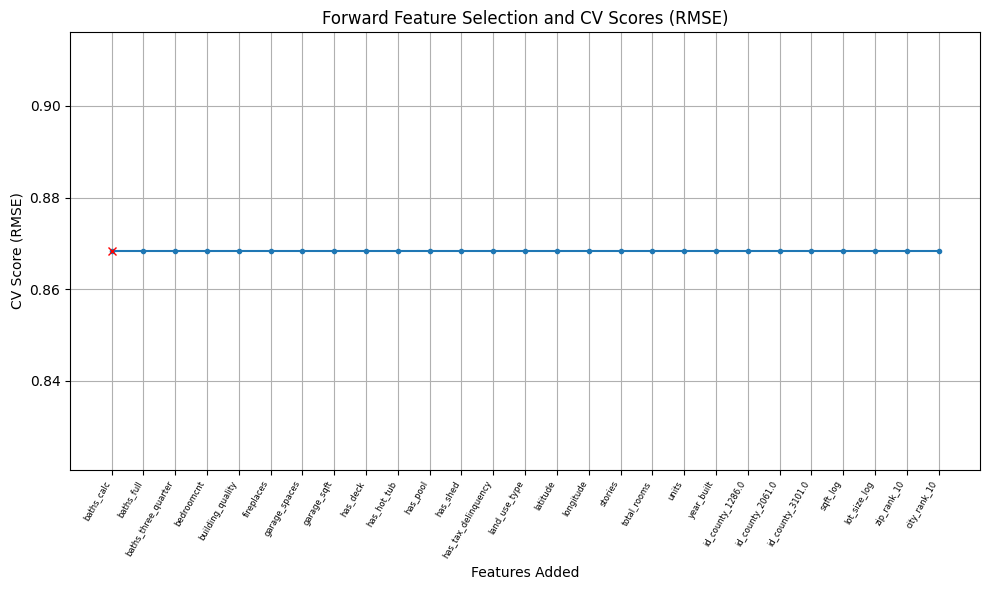

Best Features: ['baths_calc']
Best CV Score: 0.86833176


In [24]:
# Run Forward Feature Selection

## Model A forward

model = Lasso(random_state=random_seed)

selected_features, best_scores, best_forward_features, best_score =    (
            forward_feature_selection(X_train_scaled_df, y_train, model, verbose=True) )

best_scores_rmse = np.sqrt(best_scores)
best_rmse = np.sqrt(best_score)

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores_rmse) + 1), best_scores_rmse, marker='.')
plt.plot([index+1],best_rmse,marker='x',color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=60, ha='right', fontsize=6)
plt.title('Forward Feature Selection and CV Scores (RMSE)')
plt.xlabel('Features Added')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_rmse:.8f}")

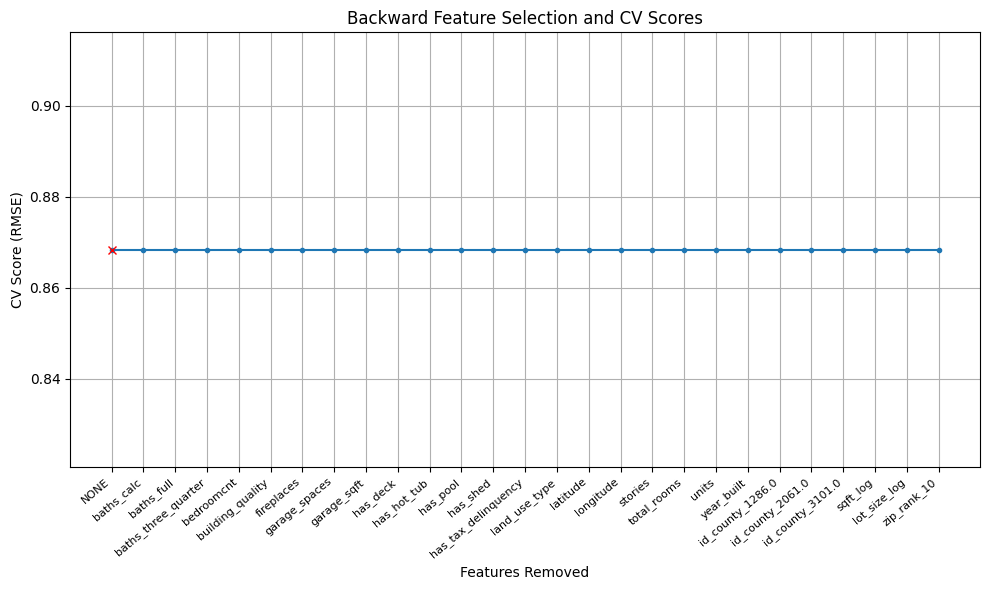

Best feature set: ['baths_calc', 'baths_full', 'baths_three_quarter', 'bedroomcnt', 'building_quality', 'fireplaces', 'garage_spaces', 'garage_sqft', 'has_deck', 'has_hot_tub', 'has_pool', 'has_shed', 'has_tax_delinquency', 'land_use_type', 'latitude', 'longitude', 'stories', 'total_rooms', 'units', 'year_built', 'id_county_1286.0', 'id_county_2061.0', 'id_county_3101.0', 'sqft_log', 'lot_size_log', 'zip_rank_10', 'city_rank_10']
CV score (RMSE): 0.8683


In [ ]:
## Model A Backwards

model = Lasso(random_state=random_seed)

selected_features, best_scores, best_feature_set, best_score = (
    backward_feature_selection(X_train_scaled_df, y_train, model, verbose=True)
)

best_scores_rmse_back = np.sqrt(best_scores)
best_rmse_back = np.sqrt(best_score)

plt.figure(figsize=(10, 6))
plt.title('Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores_rmse_back) + 1), best_scores_rmse_back, marker='.')
index = np.argmin(best_scores_rmse_back)
plt.plot([index + 1], best_scores_rmse_back[index], marker='x', color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=40, ha='right', fontsize=8)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print minimum cv score

print("Best feature set:", best_feature_set)
print("CV score (RMSE):",np.around(best_rmse_back,4))



Features: ['zip_rank_10'], CV Score (RMSE): 0.74585406

Features: ['zip_rank_10', 'baths_calc'], CV Score (RMSE): 0.67153354

Features: ['zip_rank_10', 'baths_calc', 'building_quality'], CV Score (RMSE): 0.66921709

Features: ['baths_calc', 'building_quality', 'id_county_3101.0'], CV Score (RMSE): 0.66791151

Features: ['building_quality', 'id_county_3101.0', 'land_use_type'], CV Score (RMSE): 0.66687488

Features: ['id_county_3101.0', 'land_use_type', 'has_hot_tub'], CV Score (RMSE): 0.66695433

Features: ['land_use_type', 'has_hot_tub', 'units'], CV Score (RMSE): 0.66694516

Features: ['has_hot_tub', 'units', 'baths_three_quarter'], CV Score (RMSE): 0.66688373

Features: ['units', 'baths_three_quarter', 'id_county_1286.0'], CV Score (RMSE): 0.66709535

Features: ['baths_three_quarter', 'id_county_1286.0', 'has_deck'], CV Score (RMSE): 0.66723556

Features: ['id_county_1286.0', 'has_deck', 'baths_full'], CV Score (RMSE): 0.66744647

Features: ['has_deck', 'baths_full', 'id_county_206

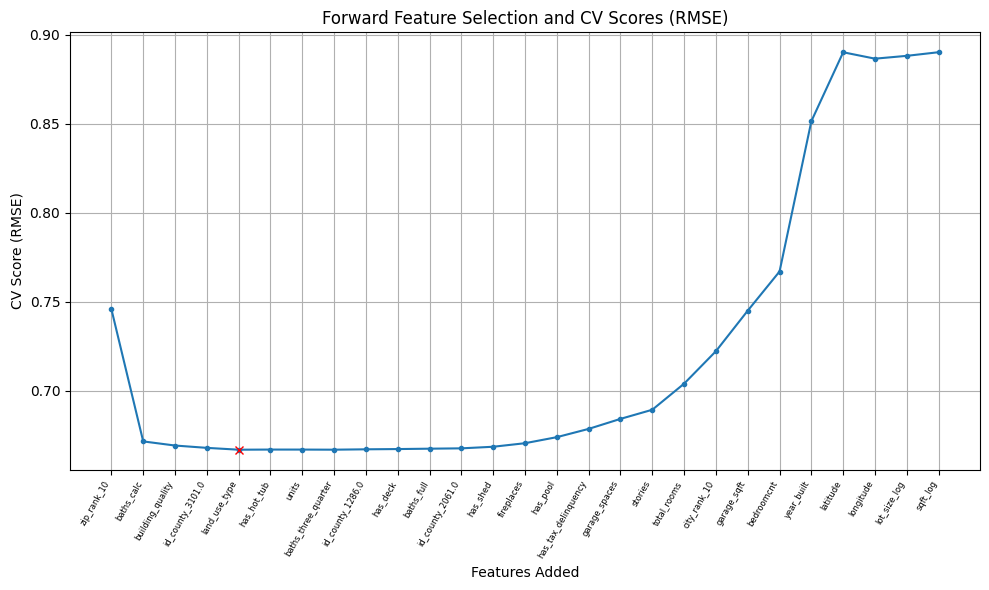

Best Features: ['zip_rank_10', 'baths_calc', 'building_quality', 'id_county_3101.0', 'land_use_type']
Best CV Score: 0.66687488


In [28]:
## Model B Forwards

model = DecisionTreeRegressor(
    random_state=random_seed
)

selected_features, best_scores, best_forward_features, best_score =    (
            forward_feature_selection(X_train_scaled_df, y_train, model, verbose=True) )

best_scores_rmse = np.sqrt(best_scores)
best_rmse = np.sqrt(best_score)

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores_rmse) + 1), best_scores_rmse, marker='.')
plt.plot([index+1],best_rmse,marker='x',color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=60, ha='right', fontsize=6)
plt.title('Forward Feature Selection and CV Scores (RMSE)')
plt.xlabel('Features Added')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_rmse:.8f}")

Start with full set of features:
['baths_calc', 'baths_full', 'baths_three_quarter', 'bedroomcnt', 'building_quality', 'fireplaces', 'garage_spaces', 'garage_sqft', 'has_deck', 'has_hot_tub', 'has_pool', 'has_shed', 'has_tax_delinquency', 'land_use_type', 'latitude', 'longitude', 'stories', 'total_rooms', 'units', 'year_built', 'id_county_1286.0', 'id_county_2061.0', 'id_county_3101.0', 'sqft_log', 'lot_size_log', 'zip_rank_10', 'city_rank_10']  CV score (RMSE): 0.8903

Round 1:
Trying removal of: baths_calc 0.8837
Trying removal of: baths_full 0.8888
Trying removal of: baths_three_quarter 0.891
Trying removal of: bedroomcnt 0.887
Trying removal of: building_quality 0.8888
Trying removal of: fireplaces 0.8892
Trying removal of: garage_spaces 0.8877
Trying removal of: garage_sqft 0.8893
Trying removal of: has_deck 0.8904
Trying removal of: has_hot_tub 0.8883
Trying removal of: has_pool 0.8903
Trying removal of: has_shed 0.8903
Trying removal of: has_tax_delinquency 0.8905
Trying removal

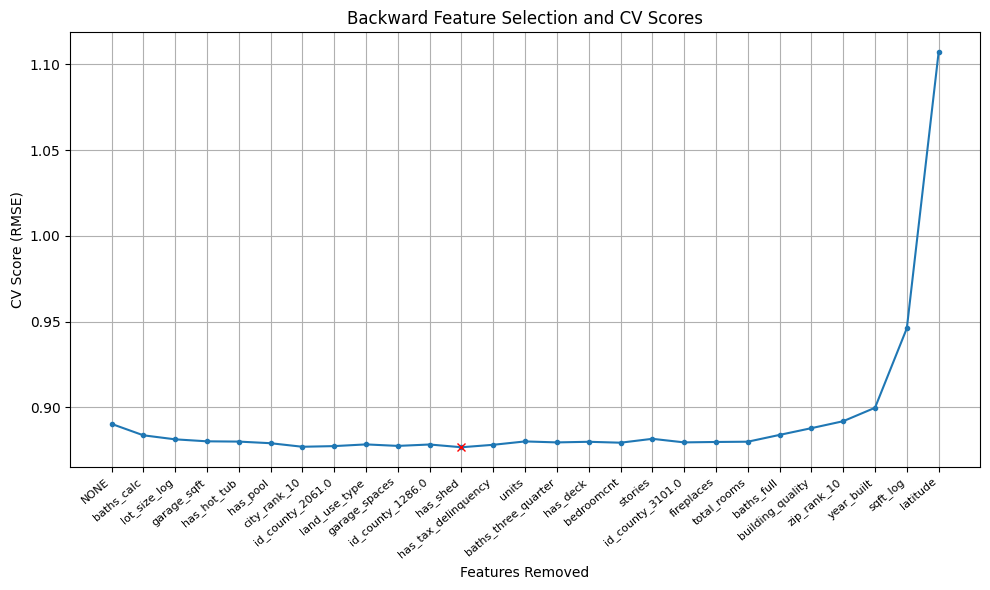

Best feature set: ['baths_full', 'baths_three_quarter', 'bedroomcnt', 'building_quality', 'fireplaces', 'has_deck', 'has_tax_delinquency', 'latitude', 'longitude', 'stories', 'total_rooms', 'units', 'year_built', 'id_county_3101.0', 'sqft_log', 'zip_rank_10']
CV score (RMSE): 0.8767


In [27]:
## Model B Backwards

model = DecisionTreeRegressor(
    random_state=random_seed
)

selected_features, best_scores, best_feature_set, best_score = (
    backward_feature_selection(X_train_scaled_df, y_train, model, verbose=True)
)

best_scores_rmse_back = np.sqrt(best_scores)
best_rmse_back = np.sqrt(best_score)

plt.figure(figsize=(10, 6))
plt.title('Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores_rmse_back) + 1), best_scores_rmse_back, marker='.')
index = np.argmin(best_scores_rmse_back)
plt.plot([index + 1], best_scores_rmse_back[index], marker='x', color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=40, ha='right', fontsize=8)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print minimum cv score

print("Best feature set:", best_feature_set)
print("CV score (RMSE):",np.around(best_rmse_back,4))

In [ ]:
## Model C forwards

model = GradientBoostingRegressor(random_state=random_seed)


selected_features, best_scores, best_forward_features, best_score =    (
            forward_feature_selection(X_train_scaled_df, y_train, model, verbose=True) )

best_scores_rmse = np.sqrt(best_scores)
best_rmse = np.sqrt(best_score)

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores_rmse) + 1), best_scores_rmse, marker='.')
plt.plot([index+1],best_rmse,marker='x',color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=60, ha='right', fontsize=6)
plt.title('Forward Feature Selection and CV Scores (RMSE)')
plt.xlabel('Features Added')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_rmse:.8f}")


Features: ['sqft_log'], CV Score (RMSE): 0.73244797


In [ ]:
## Model C Backwards

model = GradientBoostingRegressor(random_state=random_seed)

selected_features, best_scores, best_feature_set, best_score = (
    backward_feature_selection(X_train_scaled_df, y_train, model, verbose=True)
)

best_scores_rmse_back = np.sqrt(best_scores)
best_rmse_back = np.sqrt(best_score)

plt.figure(figsize=(10, 6))
plt.title('Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores_rmse_back) + 1), best_scores_rmse_back, marker='.')
index = np.argmin(best_scores_rmse_back)
plt.plot([index + 1], best_scores_rmse_back[index], marker='x', color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=40, ha='right', fontsize=8)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print minimum cv score

print("Best feature set:", best_feature_set)
print("CV score (RMSE):",np.around(best_rmse_back,4))

In [ ]:
# Model A using best features:

from sklearn.linear_model import Lasso
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

lasso = Lasso(random_state=random_seed)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    lasso,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())


In [ ]:
# Model B using best features:
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

tree = DecisionTreeRegressor(
    random_state=random_seed
)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    tree,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())


In [ ]:
# Model C using best features:

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

gbr = GradientBoostingRegressor(random_state=random_seed)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    gbr,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


> Your text here

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [ ]:
# Hyperparamtere tuning for Model A:


In [ ]:
# Hyperparamtere tuning for Model B:


In [ ]:
# Hyperparamtere tuning for Model C:


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


> Your text here

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [ ]:
# Rerun of best model with engineered features, best features, and hyperparamter tuning on training data:

In [ ]:
# Model performance on test data:

### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here